In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math


In [84]:

EPN612_FOLDER = '../data/raw/emg_epn_612/EMG-EPN612 Dataset/EMG-EPN612 Dataset'
TRAINING_FOLDER = EPN612_FOLDER + '/trainingJSON'
USER1_JSON = TRAINING_FOLDER + '/user1/user1.json'
#data/raw/emg_epn_612/EMG-EPN612 Dataset/EMG-EPN612 Dataset/trainingJSON/user1/user1.json

df = pd.read_json(USER1_JSON)
df.head(50)

,generalInfo,userInfo,synchronizationGesture,trainingSamples,testingSamples
deviceModel,Myo Armband,NaN,NaN,NaN,NaN
samplingFrequencyInHertz,200,NaN,NaN,NaN,NaN
recordingTimeInSeconds,5,NaN,NaN,NaN,NaN
repetitionsForSynchronizationGesture,5,NaN,NaN,NaN,NaN
myoPredictionLabel,"{'noGesture': 0, 'fist': 1, 'waveIn': 2, 'wave...",NaN,NaN,NaN,NaN
name,NaN,user1,NaN,NaN,NaN
age,NaN,19,NaN,NaN,NaN
gender,NaN,man,NaN,NaN,NaN
occupation,NaN,student,NaN,NaN,NaN
ethnicGroup,NaN,latin,NaN,NaN,NaN


In [85]:
trimmed = df.iloc[17:][['trainingSamples', 'testingSamples']]
trimmed.head()

,trainingSamples,testingSamples
idx_1,"{'startPointforGestureExecution': 466, 'myoDet...","{'gestureName': 'noGesture', 'startPointforGes..."
idx_2,"{'startPointforGestureExecution': 489, 'myoDet...","{'gestureName': 'noGesture', 'startPointforGes..."
idx_3,"{'startPointforGestureExecution': 173, 'myoDet...","{'gestureName': 'noGesture', 'startPointforGes..."
idx_4,"{'startPointforGestureExecution': 373, 'myoDet...","{'gestureName': 'noGesture', 'startPointforGes..."
idx_5,"{'startPointforGestureExecution': 529, 'myoDet...","{'gestureName': 'noGesture', 'startPointforGes..."


In [86]:
ssamp1 = pd.Series(trimmed['trainingSamples'][25])
ssamp1

/var/folders/dk/xl3zmt8560j1mg4qqp6f29280000gn/T/ipykernel_6527/1046123550.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ssamp1 = pd.Series(trimmed['trainingSamples'][25])


groundTruth                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
groundTruthIndex                                                        [529, 716]
startPointforGestureExecution                                                  236
myoDetection                     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
gestureName                                                                   fist
quaternion                       {'w': [0.32430000000000003, 0.3239, 0.32370000...
emg                              {'ch1': [2, 0, -2, 1, 5, -3, -3, 0, -2, -1, -1...
gyroscope                        {'x': [-1.6875, -2.4375, -0.625, 0.125, 0.9375...
accelerometer                    {'x': [0.050800000000000005, 0.0356, 0.0464000...
dtype: object

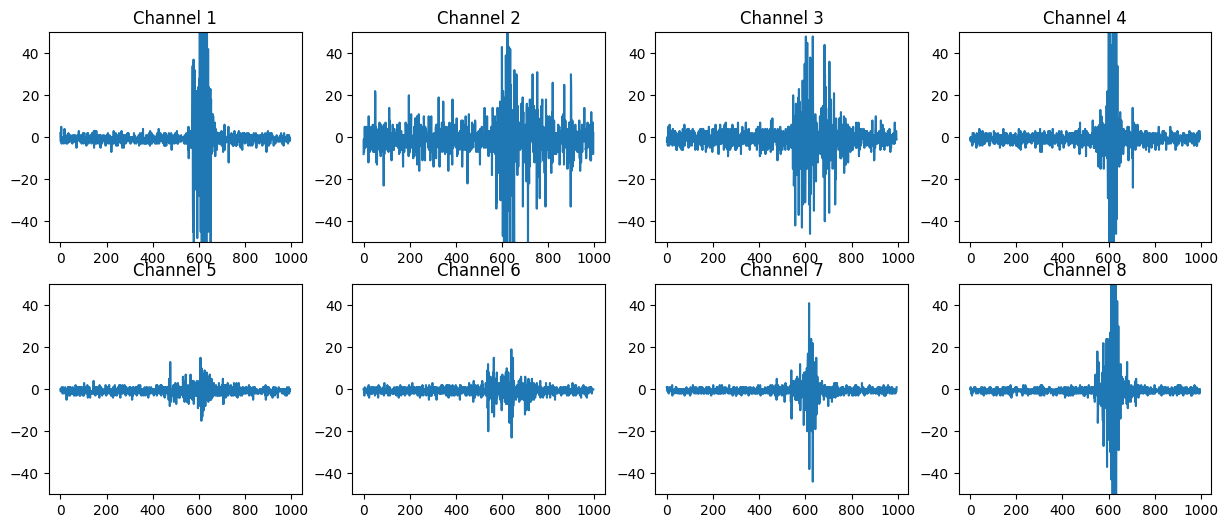

In [92]:
demg1 = ssamp1.emg
i=0
fig, ax = plt.subplots(2, 4, figsize=(15, 6))
for channel in demg1.keys():
    sch = pd.Series(demg1.get(channel))
    subplt = ax[math.floor(i/4), i%4]
    subplt.plot(sch)
    subplt.set_ylim(-50, 50)
    subplt.set_title(f"Channel {i+1}")
    i+=1



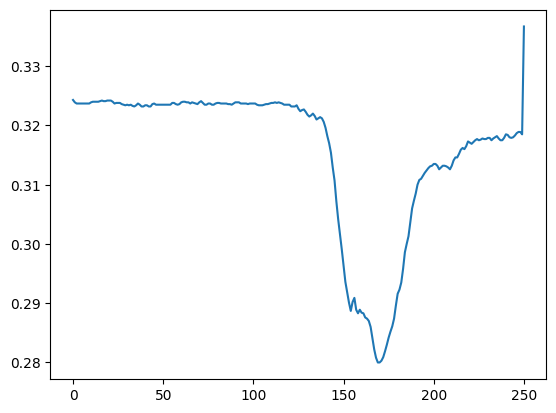

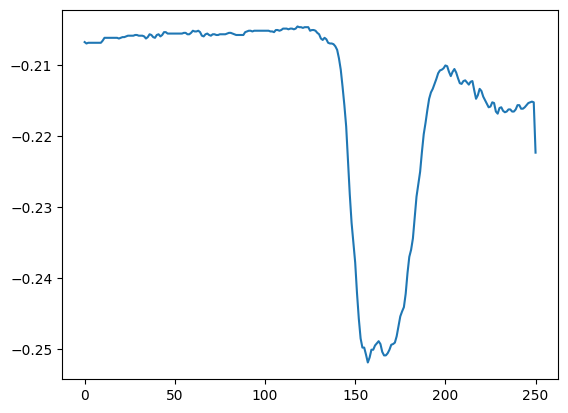

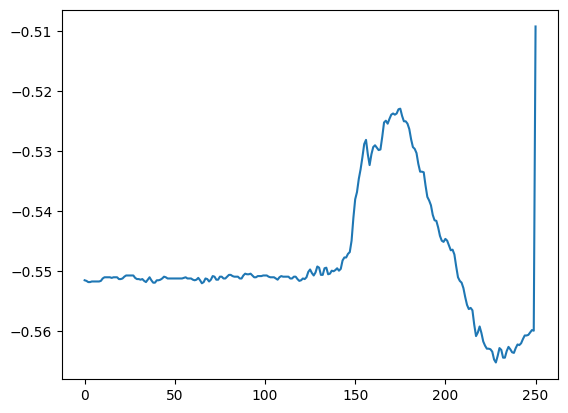

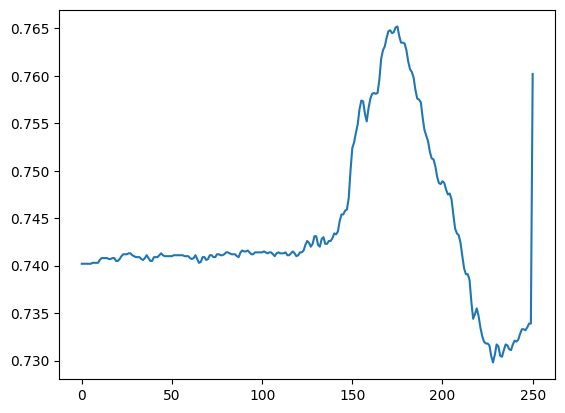

In [106]:
for k in ('w', 'x', 'y', 'z'):
    plt.plot(ssamp1.quaternion.get(k))
    plt.show()
